In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

from sklearn import set_config
set_config(transform_output="pandas")

from sklearn.metrics import silhouette_score, calinski_harabasz_score
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
from sklearn.inspection import DecisionBoundaryDisplay

# 1. Using 'price' and 'horsepower' columns from import-85.data, generate a KMeans model.
- Find the optimal value of k using elbow method, silhouette score, and calinski-harabasz score.
- Plot clusters with cluster centers.
- Show the boundaries for each cluster.


## From "imports-85.names"
  1. symboling:                -3, -2, -1, 0, 1, 2, 3.
  2. normalized-losses:        continuous from 65 to 256.
  3. make:                     alfa-romero, audi, bmw, chevrolet, dodge, honda,
                               isuzu, jaguar, mazda, mercedes-benz, mercury,
                               mitsubishi, nissan, peugot, plymouth, porsche,
                               renault, saab, subaru, toyota, volkswagen, volvo
  4. fuel-type:                diesel, gas.
  5. aspiration:               std, turbo.
  6. num-of-doors:             four, two.
  7. body-style:               hardtop, wagon, sedan, hatchback, convertible.
  8. drive-wheels:             4wd, fwd, rwd.
  9. engine-location:          front, rear.
 10. wheel-base:               continuous from 86.6 120.9.
 11. length:                   continuous from 141.1 to 208.1.
 12. width:                    continuous from 60.3 to 72.3.
 13. height:                   continuous from 47.8 to 59.8.
 14. curb-weight:              continuous from 1488 to 4066.
 15. engine-type:              dohc, dohcv, l, ohc, ohcf, ohcv, rotor.
 16. num-of-cylinders:         eight, five, four, six, three, twelve, two.
 17. engine-size:              continuous from 61 to 326.
 18. fuel-system:              1bbl, 2bbl, 4bbl, idi, mfi, mpfi, spdi, spfi.
 19. bore:                     continuous from 2.54 to 3.94.
 20. stroke:                   continuous from 2.07 to 4.17.
 21. compression-ratio:        continuous from 7 to 23.
 22. horsepower:               continuous from 48 to 288.
 23. peak-rpm:                 continuous from 4150 to 6600.
 24. city-mpg:                 continuous from 13 to 49.
 25. highway-mpg:              continuous from 16 to 54.
 26. price:                    continuous from 5118 to 45400.

In [4]:
headers = pd.read_table("names.csv", header=None)[0].to_list()
headers

['symboling',
 'normalized-losses',
 'make',
 'fuel-type',
 'aspiration',
 'num-of-doors',
 'body-style',
 'drive-wheels',
 'engine-location',
 'wheel-base',
 'length',
 'width',
 'height',
 'curb-weight',
 'engine-type',
 'num-of-cylinders',
 'engine-size',
 'fuel-system',
 'bore',
 'stroke',
 'compression-ratio',
 'horsepower',
 'peak-rpm',
 'city-mpg',
 'highway-mpg',
 'price']

In [5]:
cars = pd.read_csv("imports-85.data", header=None, names=headers)
cars

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845
201,-1,95,volvo,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045
202,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,...,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485
203,-1,95,volvo,diesel,turbo,four,sedan,rwd,front,109.1,...,145,idi,3.01,3.40,23.0,106,4800,26,27,22470


In [6]:
cars.replace("?", np.nan, inplace=True)
cars

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845
201,-1,95,volvo,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045
202,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,...,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485
203,-1,95,volvo,diesel,turbo,four,sedan,rwd,front,109.1,...,145,idi,3.01,3.40,23.0,106,4800,26,27,22470


In [7]:
cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized-losses  164 non-null    object 
 2   make               205 non-null    object 
 3   fuel-type          205 non-null    object 
 4   aspiration         205 non-null    object 
 5   num-of-doors       203 non-null    object 
 6   body-style         205 non-null    object 
 7   drive-wheels       205 non-null    object 
 8   engine-location    205 non-null    object 
 9   wheel-base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb-weight        205 non-null    int64  
 14  engine-type        205 non-null    object 
 15  num-of-cylinders   205 non-null    object 
 16  engine-size        205 non

In [8]:
cars.describe()

,symboling,wheel-base,length,width,height,curb-weight,engine-size,compression-ratio,city-mpg,highway-mpg
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,10.142537,25.219512,30.751220
std,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,3.972040,6.542142,6.886443
min,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,7.000000,13.000000,16.000000
25%,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,8.600000,19.000000,25.000000
50%,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,9.000000,24.000000,30.000000
75%,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,9.400000,30.000000,34.000000
max,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,23.000000,49.000000,54.000000


In [9]:
cars.drop_duplicates(inplace=True)

In [10]:
cars[['price', 'horsepower']].isna().sum()
# can drop since small part of data

price         4
horsepower    2
dtype: int64

In [11]:
cars.dropna(subset="price", inplace=True);
cars.dropna(subset="horsepower", inplace=True)

In [12]:
cars[['price', 'horsepower']].isna().sum()


price         0
horsepower    0
dtype: int64

In [13]:
cars["price"]

0      13495
1      16500
2      16500
3      13950
4      17450
       ...  
200    16845
201    19045
202    21485
203    22470
204    22625
Name: price, Length: 199, dtype: object

In [14]:
cars["horsepower"]

0      111
1      111
2      154
3      102
4      115
      ... 
200    114
201    160
202    134
203    106
204    114
Name: horsepower, Length: 199, dtype: object

In [15]:
cars["price"] = cars["price"].astype(float);
cars["horsepower"] = cars["horsepower"].astype(float)

In [16]:
X = cars[['price', 'horsepower']] #choose cols
X.head()

,price,horsepower
0,13495.0,111.0
1,16500.0,111.0
2,16500.0,154.0
3,13950.0,102.0
4,17450.0,115.0


In [17]:
X_scaled = StandardScaler().fit_transform(X) # scale data

In [18]:
ks = range(2,12)
s_scores = []
ch_scores = []
inertias = []
for k in ks:
    kms = KMeans(n_clusters=k, random_state=42)
    kms.fit(X_scaled)
    s_scores.append(silhouette_score(X_scaled, kms.labels_))
    ch_scores.append(calinski_harabasz_score(X_scaled, kms.labels_))
    inertias.append(kms.inertia_)

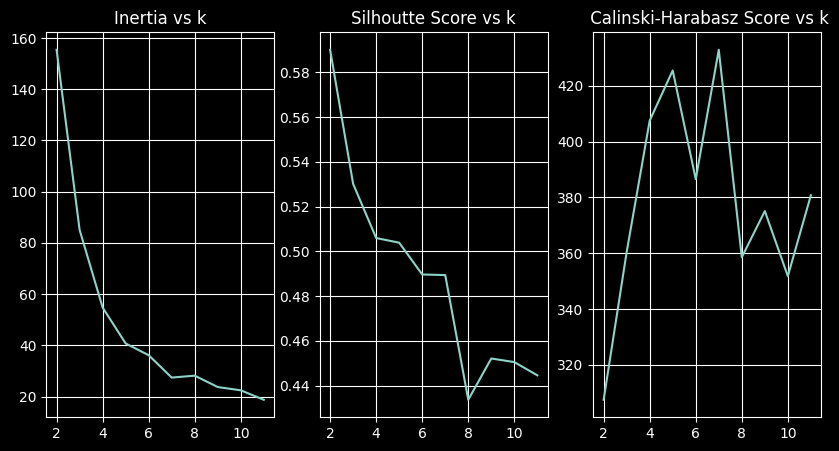

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(10, 5))

axes[0].plot(ks, inertias)
axes[0].set_title("Inertia vs k")
axes[0].grid()

axes[1].plot(ks, s_scores)
axes[1].set_title("Silhoutte Score vs k")
axes[1].grid()

axes[2].plot(ks, ch_scores)
axes[2].set_title(" Calinski-Harabasz Score vs k")
axes[2].grid()

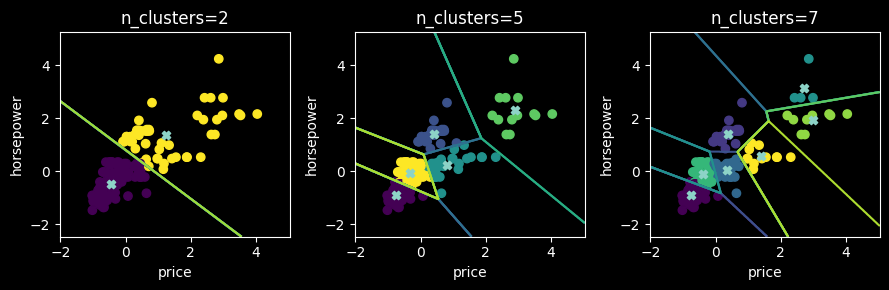

In [20]:
# 2, 5, and 7 seem to be good candidates so we examine visually
kmeans_2 = KMeans(n_clusters=2, random_state=42).fit(X_scaled)
kmeans_5 = KMeans(n_clusters=5, random_state=42).fit(X_scaled)
kmeans_7 = KMeans(n_clusters=7, random_state=42).fit(X_scaled)

fig, axes = plt.subplots(1, 3, figsize=(9, 3))

axes[0].scatter(X_scaled["price"], X_scaled["horsepower"], c=kmeans_2.labels_)
axes[0].scatter(kmeans_2.cluster_centers_[:,0], kmeans_2.cluster_centers_[:,1], marker="X")
DecisionBoundaryDisplay.from_estimator(kmeans_2, X_scaled, response_method="predict", plot_method="contour", grid_resolution=1080, ax=axes[0])
axes[0].set_title("n_clusters=2")

axes[1].scatter(X_scaled["price"], X_scaled["horsepower"], c=kmeans_5.labels_)
axes[1].scatter(kmeans_5.cluster_centers_[:,0], kmeans_5.cluster_centers_[:,1], marker="X")
DecisionBoundaryDisplay.from_estimator(kmeans_5, X_scaled, response_method="predict", plot_method="contour", grid_resolution=1080, ax=axes[1])
axes[1].set_title("n_clusters=5")

axes[2].scatter(X_scaled["price"], X_scaled["horsepower"], c=kmeans_7.labels_)
axes[2].scatter(kmeans_7.cluster_centers_[:,0], kmeans_7.cluster_centers_[:,1], marker="X")
DecisionBoundaryDisplay.from_estimator(kmeans_7, X_scaled, response_method="predict", plot_method="contour", grid_resolution=1080, ax=axes[2])
axes[2].set_title("n_clusters=7")

plt.tight_layout()

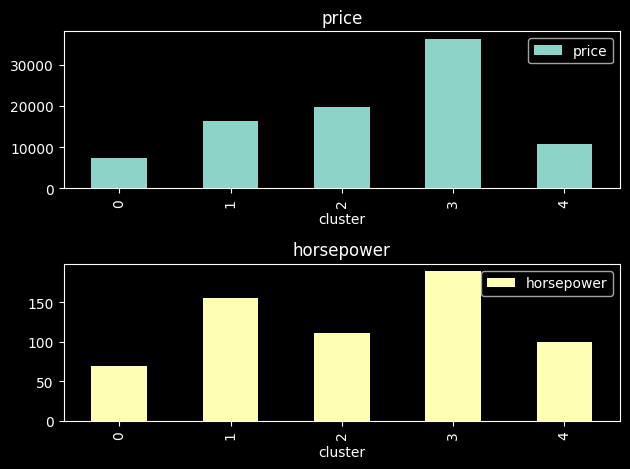

In [21]:
# 5 looks like the best clustering

X_copy = X.copy()
X_copy["cluster"] = kmeans_5.labels_
kmeans_5.transform(X_scaled)
X_clusters = X_copy.groupby("cluster")

X_clusters.mean().plot(kind="bar", subplots=True, sharex=False)
plt.tight_layout()

# 2. Using 'price' and 'horsepower' columns from import-85.data, generate a DBSCAN model.
- Plot your results to visualize outliers.


In [22]:
min_samples = 9
epsilon = 0.321

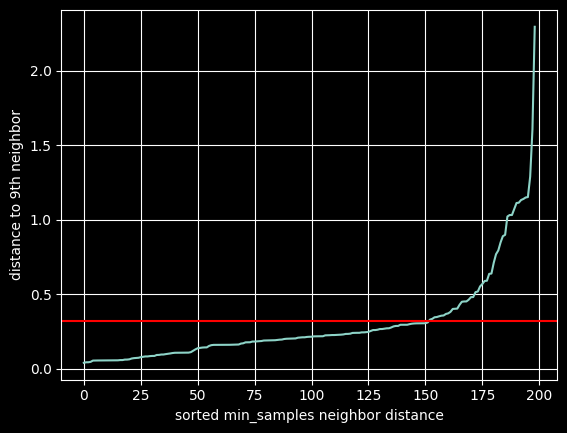

In [23]:
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors.fit(X_scaled)
distances, indices = neighbors.kneighbors(X_scaled)
n_th_neighbor = distances[:, min_samples - 1]
n_th_neighbors_sorted = np.sort(n_th_neighbor)
plt.plot(n_th_neighbors_sorted)
plt.xlabel("sorted min_samples neighbor distance")
plt.ylabel(f"distance to {min_samples}th neighbor")
plt.axhline(y=epsilon, color="r")
plt.grid()

In [24]:
db = DBSCAN(eps=epsilon, min_samples=min_samples).fit(X_scaled)
labels = db.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

Estimated number of clusters: 2
Estimated number of noise points: 30


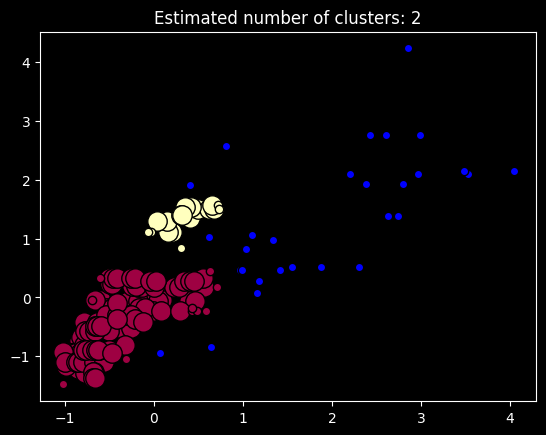

In [25]:
unique_labels = set(labels)
core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True

colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
for k, col in zip(unique_labels, colors):
    if k == -1:
        # Blue used for noise.
        col = [0, 0, 1, 1]

    class_member_mask = labels == k

    xy = X_scaled[class_member_mask & core_samples_mask]
    plt.plot(
        xy.iloc[:, 0],
        xy.iloc[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=14,
    )

    xy = X_scaled[class_member_mask & ~core_samples_mask]
    plt.plot(
        xy.iloc[:, 0],
        xy.iloc[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=6,
    )

plt.title(f"Estimated number of clusters: {n_clusters_}")
plt.show()

# 3. Using mlb_batting_cleaned.csv, write a function that takes a player's name and shows the 2 closest players using the nearest neighbors algorithm.

In [26]:
batters = pd.read_csv("mlb_batting_cleaned.csv")
batters.drop_duplicates(inplace=True)
batters_num = batters.select_dtypes(include='number')
batters_scaled = StandardScaler().fit_transform(batters_num)
nneighbors = NearestNeighbors(n_neighbors=3).fit(batters_scaled)
_, indices = nneighbors.kneighbors(batters_scaled)

In [30]:
indices[batters[batters["Name"] == "Shohei Ohtani"].index]


array([[524, 582, 238]])

In [ ]:
def nearest_batters(csv_path):
    batters = pd.read_csv(csv_path)
    batters.drop_duplicates(inplace=True)
    batters_num = batters.select_dtypes(include='number')
    batters_scaled = StandardScaler().fit_transform(batters_num)
    nneighbors = NearestNeighbors(n_neighbors=3).fit(batters_scaled)
    _, indices = nneighbors.kneighbors(batters_scaled)
    name = str(input("Input player name: "))
    idx = batters[batters["Name"] == name].index
    names = batters.iloc[indices[idx][0]]["Name"]
    first = names.iloc[1]
    second = names.iloc[2]
    print("the first closest player: " + first)
    print("the second closest player: " + second)
    return

In [32]:
nearest_batters("mlb_batting_cleaned.csv")

the first closest player: José Ramírez#
the second closest player: Freddie Freeman
